# Reencuadre fenologico del baseline — descarte geografico, modelos temporales y rama semantica

Este analisis revisita el baseline tabular cerrado previamente (F1-macro ~0.32) y pregunta tres cosas concretas:

1. **¿Aportan las features geograficas?** Se entrena el mismo modelo (XGBoost) sobre varios subconjuntos de features y se compara su F1-macro. A este experimento se le llama *ablation*: se le quita un bloque al modelo y se mide si pierde calidad. Si quitar las columnas `geom_*` (area, perimetro, elongacion de cada parcela) no degrada el F1, esas features no estaban aportando informacion util — el modelo solo las estaba usando como un proxy de la region geografica.
2. **¿Mejoran los modelos temporales?** Dos arquitecturas oficiales del benchmark BreizhCrops (TempCNN e InceptionTime) consumen la curva NDVI/NDWI/EVI reconstruida por parcela en lugar de las medias anuales que ve XGBoost. Si superan al baseline 0.32, el problema realmente era temporal y el resumen anual estaba ocultando la señal estacional.
3. **¿Hay estructura sin coordenadas?** Se hace clustering KMeans sobre la firma fenologica pura (sin `geom_*`, sin lat/lon, sin clima, sin embedding satelital general). Si los clusters separan cultivos por su forma temporal — pico, senescencia, area bajo la curva — se valida que la fenologia carga la mayor parte del problema.

El glosario al final del notebook explica los terminos tecnicos (ablation, spatial CV, out-of-fold, F1-macro).

In [1]:
# Parametros papermill. Defaults pensados para corrida FULL en GPU local;
# CI los sobrescribe a smoke con `make reencuadre-notebook-check`.
FEATURES_PATH = 'data/test_fixtures/feature_selection_parcels_subset.parquet'
MAX_SAMPLES = 0              # 0 -> dataset completo (85951 parcelas)
K_FOLDS = 5                  # spatial CV folds
BUFFER_KM = 1.0              # buffer entre folds (km)
SEED = 42
TEMPORAL_EPOCHS = 200        # epocas con early stopping (patience 20)
TEMPORAL_BATCH_SIZE = 256
DEVICE = 'auto'              # auto -> cuda si disponible, cpu si no
BASELINE_F1_MACRO = 0.32     # referencia del baseline tabular cerrado
WEAK_CLASS_THRESHOLD = 1000  # umbral de soporte por clase (parcelas)
N_CLUSTERS = 6               # KMeans para clustering sin coordenadas
FIGURES_DIR = 'paper/figures/reencuadre_fenologico'
REPORTS_DIR = 'reports/baseline'
ARTIFACTS_DIR = 'reports/baseline/reencuadre_fenologico'  # datos crudos de las graficas
CHECKPOINTS_DIR = 'models/checkpoints/phenology'  # .pt de los modelos entrenados
MLFLOW_TRACKING_URI = ''     # vacio -> sin MLflow; con valor -> URI persistente
FARSLIP_PARQUET_PATH = 'data/farslip/embeddings_italy.parquet'
RUN_TEMPORAL = True          # entrena TempCNN/InceptionTime
RUN_SEMANTIC_BRANCH = False  # rama semantica: requiere Gemini API + budget


In [2]:
# Parameters
MAX_SAMPLES = 800
K_FOLDS = 3
BUFFER_KM = 0.5
TEMPORAL_EPOCHS = 2
TEMPORAL_BATCH_SIZE = 32
DEVICE = "cpu"
RUN_SEMANTIC_BRANCH = False


In [3]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

# Bootstrap sys.path subiendo niveles hasta encontrar pyproject.toml.
_REPO_BOOTSTRAP = Path.cwd().resolve()
for _candidate in (_REPO_BOOTSTRAP, *_REPO_BOOTSTRAP.parents):
    if (_candidate / 'pyproject.toml').is_file():
        _REPO_BOOTSTRAP = _candidate
        break
if str(_REPO_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_REPO_BOOTSTRAP))

from ml.utils.notebook_setup import find_repo_root

REPO = find_repo_root()
FIGURES = REPO / FIGURES_DIR
REPORTS = REPO / REPORTS_DIR
ARTIFACTS = REPO / ARTIFACTS_DIR
CHECKPOINTS = REPO / CHECKPOINTS_DIR
FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)
ARTIFACTS.mkdir(parents=True, exist_ok=True)
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

# Helper de log visible en el notebook (timestamp + mensaje).
import datetime as _dt
_T0_NB = _dt.datetime.now()
def log(msg: str, *, level: str = 'info') -> None:
    """Imprime un log con timestamp HH:MM:SS y delta desde el inicio."""
    now = _dt.datetime.now()
    delta_s = (now - _T0_NB).total_seconds()
    badge = {'info': '[i]', 'ok': '[+]', 'warn': '[!]', 'step': '[#]'}.get(level, '[i]')
    print(f'{now.strftime("%H:%M:%S")}  +{delta_s:6.1f}s  {badge}  {msg}', flush=True)

pl.Config.set_tbl_formatting('ASCII_MARKDOWN')
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

get_ipython().run_line_magic('matplotlib', 'inline')
get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'png'")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200

import torch
_cuda_available = torch.cuda.is_available()
_cuda_name = torch.cuda.get_device_name(0) if _cuda_available else 'N/A'
_effective_device = ('cuda' if _cuda_available else 'cpu') if DEVICE == 'auto' else DEVICE
display(Markdown(
    f'**Setup**: repo `{REPO.name}` · polars `{pl.__version__}` · '
    f'torch `{torch.__version__}` · device `{_effective_device}` ({_cuda_name})\n\n'
    f'**Figuras**: `{FIGURES.relative_to(REPO)}` · '
    f'**Reportes**: `{REPORTS.relative_to(REPO)}`\n\n'
    f'**Artefactos de graficas** (parquet/npz): `{ARTIFACTS.relative_to(REPO)}`\n\n'
    f'**Checkpoints de modelos** (.pt): `{CHECKPOINTS.relative_to(REPO)}`'
))
log(f'bootstrap completo · device={_effective_device}', level='ok')


**Setup**: repo `agrosat-copilot` · polars `1.40.1` · torch `2.11.0+cu130` · device `cpu` (N/A)

**Figuras**: `paper\figures\reencuadre_fenologico` · **Reportes**: `reports\baseline`

**Artefactos de graficas** (parquet/npz): `reports\baseline\reencuadre_fenologico`

**Checkpoints de modelos** (.pt): `models\checkpoints\phenology`

06:41:52  +   2.8s  [+]  bootstrap completo · device=cpu


## 2. Carga del dataset y el desbalance entre clases

El subset cargado contiene parcelas PASTIS-R italianas con 18 cultivos efectivos (se descartan las clases `Background` y `Void`, que no son agronomicas). La razon principal por la que el baseline cerro en F1-macro 0.32 y no en 0.50 es el **desbalance**: la clase mayoritaria tiene ~31x el numero de parcelas de la minoritaria, asi que el modelo acierta bien en pocas clases y destruye el promedio.

In [4]:
from ml.train.baseline import _load_baseline_dataset, _prepare_dataframe

log('cargando dataset...', level='step')
df_raw = _load_baseline_dataset(FEATURES_PATH)
log(f'parquet cargado: {df_raw.height:,} filas x {df_raw.width} cols')
df = _prepare_dataframe(df_raw)
log(f'filtrado (clases agronomicas): {df.height:,} parcelas')
if MAX_SAMPLES > 0 and df.height > MAX_SAMPLES:
    df = df.sample(n=MAX_SAMPLES, seed=SEED, with_replacement=False)
    log(f'subsampled a MAX_SAMPLES={MAX_SAMPLES:,}', level='warn')
log(f'dataset listo: {df.height:,} parcelas x {df.width} cols', level='ok')

display(Markdown(
    f'**Parcelas tras subsample**: `{df.height:,}` filas × `{df.width}` columnas'
))
df.head(3)


06:41:55  +   5.5s  [#]  cargando dataset...


06:41:55  +   5.8s  [i]  parquet cargado: 85,951 filas x 192 cols


06:41:55  +   5.8s  [i]  filtrado (clases agronomicas): 85,951 parcelas


06:41:55  +   5.8s  [!]  subsampled a MAX_SAMPLES=800


06:41:55  +   5.8s  [+]  dataset listo: 800 parcelas x 192 cols


**Parcelas tras subsample**: `800` filas × `192` columnas

parcel_id,year,NDVI_mean,NDVI_std,NDVI_min,NDVI_max,NDVI_p05,NDVI_p25,NDVI_p50,NDVI_p75,NDVI_p95,NDWI_mean,NDWI_std,NDWI_min,NDWI_max,NDWI_p05,NDWI_p25,NDWI_p50,NDWI_p75,NDWI_p95,EVI_mean,EVI_std,EVI_min,EVI_max,EVI_p05,EVI_p25,EVI_p50,EVI_p75,EVI_p95,NDMI_mean,NDMI_std,NDMI_min,NDMI_max,NDMI_p05,NDMI_p25,NDMI_p50,NDMI_p75,…,NDVI_fft_amp_0,NDVI_fft_phase_0,NDVI_fft_amp_1,NDVI_fft_phase_1,NDVI_fft_amp_2,NDVI_fft_phase_2,NDVI_fft_amp_3,NDVI_fft_phase_3,NDWI_fft_amp_0,NDWI_fft_phase_0,NDWI_fft_amp_1,NDWI_fft_phase_1,NDWI_fft_amp_2,NDWI_fft_phase_2,NDWI_fft_amp_3,NDWI_fft_phase_3,EVI_fft_amp_0,EVI_fft_phase_0,EVI_fft_amp_1,EVI_fft_phase_1,EVI_fft_amp_2,EVI_fft_phase_2,EVI_fft_amp_3,EVI_fft_phase_3,sog_doy,peak_doy,peak_value,senescence_doy,ndvi_auc,ndvi_slope_pre_peak,ndvi_slope_post_peak,maturity_duration_days,patch_id,instance_id,class_id,fold,n_pixels
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64
"""40122_47""",2018,0.530494,0.266397,-0.030714,1.0,0.024816,0.360473,0.488305,0.775717,0.882688,-0.519276,0.229263,-0.959894,0.070101,-0.771777,-0.694916,-0.534834,-0.424551,-0.060516,0.348573,0.192286,-0.043692,0.728491,0.017703,0.225483,0.314487,0.53555,0.644069,0.284848,0.620014,-0.132385,3.779812,-0.052833,0.055666,0.140717,0.310371,…,0.48577,0.0,0.252691,2.07978,0.121423,0.312828,0.055785,1.62398,0.494976,0.0,0.185642,-1.094255,0.105858,-2.936903,0.023043,-2.306283,0.328585,0.0,0.178893,2.244486,0.082686,-0.299449,0.070718,0.89078,15,321,1.0,null,189.526471,0.001825,null,3,40122,47,2,1,50
"""20222_5""",2018,0.373932,0.333581,-0.0,2.560521,0.07863,0.224837,0.30802,0.414026,0.708648,-0.14,2.17098,-0.794251,16.636106,-0.636116,-0.503878,-0.43127,-0.368374,-0.062743,0.240345,0.139937,0.0,0.644488,0.124259,0.155814,0.179544,0.290631,0.520611,0.033207,0.137787,-0.161013,0.408253,-0.126064,-0.061108,-0.001587,0.111764,…,0.375842,0.0,0.148343,2.579003,0.163024,-1.307821,0.049594,0.813086,0.093577,0.0,0.569561,2.044395,0.60727,-2.051199,0.638104,0.081292,0.243368,0.0,0.063127,2.832208,0.128132,-0.857955,0.041274,-3.037942,7,271,2.560521,302,152.26757,0.00176,-0.03545,4,20222,5,4,2,27
"""40503_23""",2018,0.458928,0.221938,-0.029795,0.875562,0.033441,0.418358,0.479999,0.518118,0.837363,-0.489947,0.209141,-0.775712,0.041467,-0.718518,-0.593768,-0.562544,-0.489757,-0.058504,0.326406,0.166206,-0.153176,0.736593,0.095239,0.25727,0.302242,0.380225,0.672457,0.03623,0.148204,-0.131912,0.416705,-0.126725,-0.072418,-0.009186,0.122032,…,0.456771,0.0,0.14155,2.276248,0.143415,-0.273467,0.075839,-2.081231,0.47726,0.0,0.124285,-1.296928,0.125072,3.117212,0.105266,1.062769,0.330318,0.0,0.140984,2.507242,0.100498,-0.646449,0.021082,0.514453,131,261,0.875562,272,178.157731,0.0017,-0.055911,5,40503,23,1,5,19


In [5]:
# Intenta inyectar el bloque FarSLIP (512-dim) si el parquet existe.
# Si no existe (corrida normal del A3), la ablation omite los
# conjuntos `with_farslip` y `farslip_only` automaticamente.
farslip_path = REPO / FARSLIP_PARQUET_PATH
if farslip_path.is_file():
    farslip_df = pl.read_parquet(farslip_path)
    pre = df.width
    df = df.join(farslip_df, on='parcel_id', how='left')
    new_cols = df.width - pre
    display(Markdown(
        f'**FarSLIP integrado**: +{new_cols} columnas '
        f'(`{farslip_path.relative_to(REPO)}`) — los conjuntos '
        f'`with_farslip` y `farslip_only` apareceran en la ablation.'
    ))
else:
    display(Markdown(
        f'**FarSLIP no materializado** (`{farslip_path.relative_to(REPO)}` no existe). '
        f'La ablation omite los conjuntos `with_farslip` y `farslip_only`. '
        f'Para materializarlo se ejecuta el pipeline FarSLIP (US-022b-B) en GPU.'
    ))


**FarSLIP no materializado** (`data\farslip\embeddings_italy.parquet` no existe). La ablation omite los conjuntos `with_farslip` y `farslip_only`. Para materializarlo se ejecuta el pipeline FarSLIP (US-022b-B) en GPU.

In [6]:
# Distribucion de clases efectivas + ratio max/min.
class_counts = (
    df.group_by('class_id').len().sort('len', descending=True)
    .with_columns((pl.col('len') / df.height * 100).round(2).alias('pct'))
)
imbalance_ratio = (
    class_counts['len'].max() / max(class_counts['len'].min(), 1)
    if class_counts.height > 0 else float('nan')
)
class_counts.write_parquet(ARTIFACTS / 'class_counts.parquet')
log(f'class_counts persistido (n_clases={class_counts.height})', level='ok')
display(Markdown(
    f'**Clases efectivas**: `{class_counts.height}` · '
    f'**Ratio max/min**: `{imbalance_ratio:.1f}x`'
))
class_counts


06:41:55  +   5.9s  [+]  class_counts persistido (n_clases=18)


**Clases efectivas**: `18` · **Ratio max/min**: `94.0x`

class_id,len,pct
i64,u32,f64
1,282,35.25
3,136,17.0
8,119,14.88
2,66,8.25
16,27,3.38
4,27,3.38
12,26,3.25
14,23,2.88
10,14,1.75


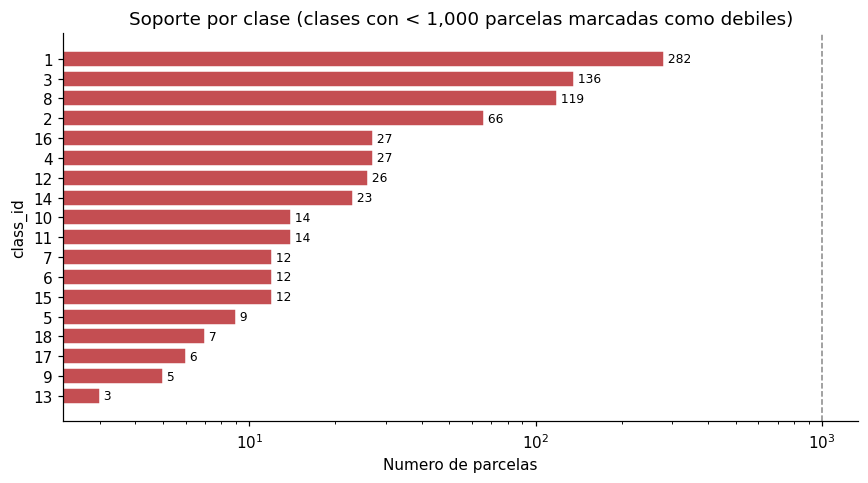

In [7]:
# Grafica del desbalance: clases con soporte debil (< umbral) en rojo.
from ml.eval.reencuadre_plots import plot_class_support_bars

fig = plot_class_support_bars(
    class_counts,
    weak_threshold=WEAK_CLASS_THRESHOLD,
    title=(
        f'Soporte por clase (clases con < {WEAK_CLASS_THRESHOLD:,} '
        f'parcelas marcadas como debiles)'
    ),
)
fig.savefig(FIGURES / 'class_support.png', bbox_inches='tight')
plt.show()


## 3. Ablation de features — ¿aportan las columnas geograficas?

Se entrena XGBoost (el mismo modelo del baseline) sobre cinco subconjuntos de features, manteniendo identico el spatial CV (3 folds, buffer 0.5 km) y la semilla. El delta de F1-macro entre cada set y el set `full` cuantifica el valor incremental de cada bloque:

- **`full`**: todas las features disponibles en el subset.
- **`no_geom`**: idem sin las tres columnas `geom_*` (area, perimetro, elongacion).
- **`no_geom_no_era5_srtm`**: ademas sin clima ERA5 ni topografia SRTM, que el embedding satelital general ya codifica internamente.
- **`alphaearth_only`**: solo los 64 embeddings del modelo satelital general.
- **`phenology_only`**: solo features fenologicas (pico, senescencia, area bajo la curva NDVI) y armonicos FFT de la serie temporal.

Si `no_geom` no degrada F1-macro, las `geom_*` se descartan en las siguientes fases. Si `phenology_only` se acerca a `full`, validamos la hipotesis de que la fenologia carga el problema.

In [8]:
from ml.eval.feature_ablation import (
    build_default_feature_sets,
    export_ablation_table,
    run_feature_ablation,
)

feature_sets = build_default_feature_sets(df.columns)
sets_summary = pl.DataFrame([
    {'feature_set': name, 'n_features': len(cols)}
    for name, cols in feature_sets.items()
])
display(Markdown('**Conjuntos a evaluar**:'))
sets_summary


**Conjuntos a evaluar**:

feature_set,n_features
str,i64
"""full""",185
"""no_geom""",185
"""no_geom_no_era5_srtm""",185
"""alphaearth_only""",0
"""phenology_only""",32


In [9]:
# Ablation: 5+ sets x XGBoost, mismo spatial CV.
log(f'lanzando ablation: {len(feature_sets)} conjuntos x XGBoost, k_folds={K_FOLDS}', level='step')
ablation_results = run_feature_ablation(
    df=df,
    feature_sets=feature_sets,
    models=('xgb',),
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    seed=SEED,
)
log(f'ablation terminada: {len(ablation_results)} resultados', level='ok')
ablation_table = pl.DataFrame([
    {
        'feature_set': r.feature_set,
        'n_features': r.n_features,
        'f1_macro': round(r.f1_macro, 4),
        'f1_weighted': round(r.f1_weighted, 4),
        'miou': round(r.miou, 4),
        'delta_vs_full': (
            round(r.delta_vs_full, 4)
            if r.delta_vs_full == r.delta_vs_full else None
        ),
    }
    for r in ablation_results
]).sort('f1_macro', descending=True)
ablation_table


06:41:56  +   6.5s  [#]  lanzando ablation: 5 conjuntos x XGBoost, k_folds=3


2026-05-24 06:41:56 [info     ] ablation_start                 models=('xgb',) n_rows=800 n_sets=5


2026-05-24 06:41:56 [info     ] spatial_folds_cache_hit        n_folds=3 path=data\test_fixtures\baseline_spatial_folds_n800_k3_b0p5_s42.parquet


2026-05-24 06:41:56 [info     ] spatial_cv_start               n_classes=18 n_folds=3


2026-05-24 06:41:56 [info     ] spatial_cv_fold_start          fold=1/3 n_test=223 n_train=577


...

2026-05-24 06:44:39 [info     ] baseline_trained               f1_macro_oof=0.15477097189779326 model=xgb n_classes=18 n_features=32 n_samples=800


2026-05-24 06:44:39 [info     ] ablation_cell_done             f1_macro=0.1548 feature_set=phenology_only model_kind=xgb n_features=32


2026-05-24 06:44:39 [info     ] ablation_done                  n_rows_output=5


06:44:39  + 169.0s  [+]  ablation terminada: 5 resultados


feature_set,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,i64,f64,f64,f64,f64
"""alphaearth_only""",0,NaN,NaN,NaN,null
"""full""",185,0.206,0.5788,0.1497,null
"""no_geom""",185,0.206,0.5788,0.1497,0.0
"""no_geom_no_era5_srtm""",185,0.206,0.5788,0.1497,0.0
"""phenology_only""",32,0.1548,0.4415,0.1026,-0.0512


In [10]:
# Persistencia: CSV + Markdown + parquet de datos crudos.
csv_path, md_path = export_ablation_table(
    ablation_results, REPORTS / 'feature_ablation'
)
ablation_table.write_parquet(ARTIFACTS / 'ablation_table.parquet')
log(f'ablation persistida: {csv_path.name} + ablation_table.parquet', level='ok')
display(Markdown(f'**Tabla persistida**: `{csv_path.name}` + `{md_path.name}`'))


2026-05-24 06:44:39 [info     ] ablation_table_exported        csv='D:\\Master Degree\\2026-2do Trimestre\\Integrador\\git\\agrosat-copilot\\reports\\baseline\\feature_ablation.csv' md='D:\\Master Degree\\2026-2do Trimestre\\Integrador\\git\\agrosat-copilot\\reports\\baseline\\feature_ablation.md'


06:44:39  + 169.1s  [+]  ablation persistida: feature_ablation.csv + ablation_table.parquet


**Tabla persistida**: `feature_ablation.csv` + `feature_ablation.md`

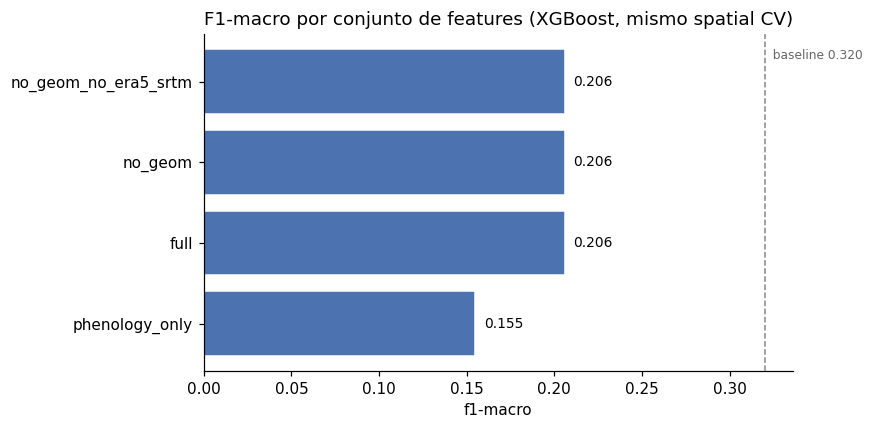

In [11]:
# Grafica de F1-macro por conjunto de features, con linea del baseline.
from ml.eval.reencuadre_plots import plot_ablation_bars

fig = plot_ablation_bars(
    ablation_results,
    metric='f1_macro',
    baseline_value=BASELINE_F1_MACRO,
    title='F1-macro por conjunto de features (XGBoost, mismo spatial CV)',
)
fig.savefig(FIGURES / 'ablation_xgb.png', bbox_inches='tight')
plt.show()


### 3.1 Lectura de los deltas

La columna `delta_vs_full` reporta cuanto F1-macro se gana o se pierde al pasar de `full` al subset correspondiente:

- **Si `no_geom.delta_vs_full` es ≥ 0** las columnas `geom_*` no aportaban; en el mejor caso eran ruido, en el peor un proxy de la region (es decir, leakage espacial). Se eliminan en las siguientes fases.
- **Si `no_geom_no_era5_srtm.delta_vs_full` se mantiene** las features de clima y topografia crudas eran redundantes con el embedding satelital general.
- **Si `phenology_only` queda cerca de `full`** la firma fenologica explicita (pico, senescencia, FFT) carga la mayor parte de la señal — exactamente el argumento del paper Wen et al. 2025.

## 4. Comparativa de modelos — XGBoost vs TempCNN vs InceptionTime

Sobre el subconjunto de features ganador de la seccion 3 se entrenan tres modelos con el mismo spatial CV:

- **XGBoost**: gradient boosting tabular, ve estadisticas resumen anuales.
- **TempCNN** (Pelletier et al. 2019): CNN 1D con kernels estrechos sobre la dimension temporal. Importado de `breizhcrops.models`, no reimplementado.
- **InceptionTime** (Fawaz et al. 2020): bloques Inception adaptados a series. Tambien importado de `breizhcrops.models`.

Los dos modelos temporales reciben la curva NDVI/NDWI/EVI reconstruida por parcela (T=72 muestras a 5 dias) en lugar de las medias y percentiles anuales. La meta es superar el F1-macro del baseline tabular 0.32; el target deseable es ~0.45.

In [12]:
# Identifica el conjunto de features ganador segun la tabla de la seccion 3.
# Filtra filas con f1_macro NaN/null ANTES de pickear el row 0: en Polars
# `sort(descending=True)` deja los NaN arriba, lo cual elegiria un set vacio
# como `alphaearth_only` que no entreno (ver `ablation_set_empty` en logs).
_valid_ablation = ablation_table.filter(
    pl.col('f1_macro').is_not_nan() & pl.col('f1_macro').is_not_null()
)
if _valid_ablation.height == 0:
    raise RuntimeError(
        'Todas las filas de ablation tienen f1_macro NaN/null. '
        'Revisa los logs upstream (cell 11) por errores de training.'
    )
winner_row = _valid_ablation.row(0, named=True)
winner_set = winner_row['feature_set']
winner_f1 = winner_row['f1_macro']
display(Markdown(
    f'**Conjunto ganador**: `{winner_set}` con F1-macro `{winner_f1:.4f}` '
    f'(de {_valid_ablation.height}/{ablation_table.height} filas validas).'
))


**Conjunto ganador**: `full` con F1-macro `0.2060` (de 4/5 filas validas).

In [13]:
# Entrena los tres modelos sobre el mismo subconjunto ganador.
from ml.train.phenology_models import train_temporal_model

model_results = {}
# Fix US-022c P2: si el ganador no tiene fila XGB (puede pasar por desempate
# entre conjuntos con el mismo F1, o por discrepancia 'xgb' vs 'xgboost'),
# usa el mejor XGB global de toda la ablation como fallback.
xgb_winner = next(
    (r for r in ablation_results if r.feature_set == winner_set and r.model_kind == 'xgb'),
    None,
)
if xgb_winner is None:
    xgb_results = [r for r in ablation_results if r.model_kind == 'xgb']
    if xgb_results:
        xgb_winner = max(xgb_results, key=lambda r: r.f1_macro)
if xgb_winner is not None:
    model_results['xgboost'] = xgb_winner

temporal_results = {}
if RUN_TEMPORAL:
    for kind in ('tempcnn', 'inceptiontime'):
        log(f'entrenando {kind} ({TEMPORAL_EPOCHS} epocas, batch={TEMPORAL_BATCH_SIZE}, device={DEVICE})...', level='step')
        result = train_temporal_model(
            df=df,
            model_kind=kind,
            n_epochs=TEMPORAL_EPOCHS,
            batch_size=TEMPORAL_BATCH_SIZE,
            seed=SEED,
            device=DEVICE,
            mlflow_uri=MLFLOW_TRACKING_URI or None,
            sequence_length=72,
            indices=('NDVI', 'NDWI', 'EVI'),
            k_folds=K_FOLDS,
            buffer_km=BUFFER_KM,
            checkpoint_dir=CHECKPOINTS,
            dropout=0.2,                        # paper-faro Wen: 0.2-0.3 para T=72
            use_class_weights=True,             # balancea CrossEntropy con freq inversa
            use_weighted_sampler=True,          # cada batch ve todas las clases
            use_lr_scheduler=True,              # warmup + cosine annealing
            warmup_epochs=5,
            early_stopping_patience=20,         # 20 epochs sin mejora -> stop
            val_fraction=0.15,                  # 15% del fold para early stopping
        )
        temporal_results[kind] = result
        model_results[kind] = result
        log(
            f'{kind}: F1-macro={result.f1_macro:.4f} mIoU={result.miou:.4f} '
            f't={result.train_time_s:.1f}s ckpt={result.checkpoint_path.name if result.checkpoint_path else "-"}',
            level='ok',
        )
else:
    log('RUN_TEMPORAL=False -> seccion 4 omitida.', level='warn')


06:44:39  + 169.8s  [#]  entrenando tempcnn (2 epocas, batch=32, device=cpu)...


2026-05-24 06:44:39 [info     ] spatial_folds_cache_hit        n_folds=3 path=data\test_fixtures\baseline_spatial_folds_n800_k3_b0p5_s42.parquet


2026-05-24 06:44:39 [info     ] temporal_class_weights         imbalance_ratio=94.0 max_weight=14.814814814814815 min_weight=0.15760441292356187


2026-05-24 06:44:42 [info     ] temporal_fold_done             f1_macro=0.0203 fold=1/3 model_kind=tempcnn


2026-05-24 06:44:43 [info     ] temporal_fold_done             f1_macro=0.025 fold=2/3 model_kind=tempcnn


...

2026-05-24 06:44:53 [info     ] temporal_fold_done             f1_macro=0.033 fold=2/3 model_kind=inceptiontime


2026-05-24 06:44:56 [info     ] temporal_fold_done             f1_macro=0.0074 fold=3/3 model_kind=inceptiontime


2026-05-24 06:44:56 [info     ] temporal_checkpoint_saved      f1_macro=0.0211 path='D:\\Master Degree\\2026-2do Trimestre\\Integrador\\git\\agrosat-copilot\\models\\checkpoints\\phenology\\inceptiontime_b8cc7b5_f1_0p0211_seed42.pt'


2026-05-24 06:44:56 [info     ] temporal_train_done            f1_macro=0.0211 model_kind=inceptiontime n_classes=18 n_parcels=800 train_time_s=12.29


06:44:56  + 186.5s  [+]  inceptiontime: F1-macro=0.0211 mIoU=0.0110 t=12.3s ckpt=inceptiontime_b8cc7b5_f1_0p0211_seed42.pt


In [14]:
# Tabla comparativa de los tres modelos sobre el mismo set.
comparison_rows = []
if model_results.get('xgboost') is not None:
    xgb_r = model_results['xgboost']
    comparison_rows.append({
        'model': 'xgboost',
        'f1_macro': round(xgb_r.f1_macro, 4),
        'f1_weighted': round(xgb_r.f1_weighted, 4),
        'miou': round(xgb_r.miou, 4),
        'delta_vs_baseline': round(xgb_r.f1_macro - BASELINE_F1_MACRO, 4),
    })
for kind, r in temporal_results.items():
    comparison_rows.append({
        'model': kind,
        'f1_macro': round(r.f1_macro, 4),
        'f1_weighted': round(r.f1_weighted, 4),
        'miou': round(r.miou, 4),
        'delta_vs_baseline': round(r.f1_macro - BASELINE_F1_MACRO, 4),
    })
comparison_table = pl.DataFrame(comparison_rows).sort('f1_macro', descending=True)
# Defensa US-022c P2: NaN o null en f1_macro indica que XGB no produjo
# metricas validas (lookup vacio O entrenamiento upstream tronado).
# Polars: is_null y is_nan son distintos; XGB falla produciendo NaN
# (no null), por eso chequeamos AMBOS para no callar silenciosamente.
if comparison_table.height > 0 and 'f1_macro' in comparison_table.columns:
    _bad_metrics = comparison_table['f1_macro'].is_null() | comparison_table['f1_macro'].is_nan()
    assert not _bad_metrics.any(), (
        f'XGBoost NaN bug (US-022c P2): {_bad_metrics.sum()} fila(s) sin metricas validas. '
        'Revisa los logs de la ablation upstream (cell 11) — el training XGB '
        'puede haber tronado con "Invalid classes inferred from unique values of y".'
    )
comparison_table.write_parquet(ARTIFACTS / 'model_comparison.parquet')
log(f'comparativa de modelos persistida: model_comparison.parquet ({len(comparison_rows)} filas)', level='ok')
# Persistencia
comparison_table.write_csv(REPORTS / 'phenology_models.csv')
display(Markdown(f'**Tabla comparativa persistida**: `phenology_models.csv`'))
comparison_table


06:44:56  + 186.5s  [+]  comparativa de modelos persistida: model_comparison.parquet (3 filas)


**Tabla comparativa persistida**: `phenology_models.csv`

model,f1_macro,f1_weighted,miou,delta_vs_baseline
str,f64,f64,f64,f64
"""xgboost""",0.206,0.5788,0.1497,-0.114
"""tempcnn""",0.0295,0.0179,0.0157,-0.2905
"""inceptiontime""",0.0211,0.0156,0.011,-0.2989


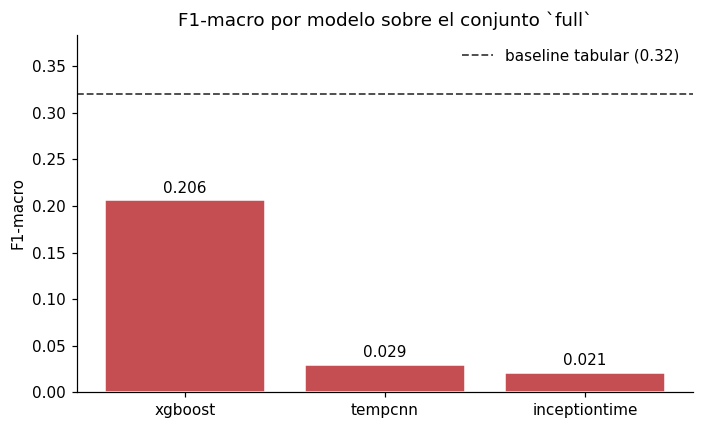

In [15]:
# Grafica de F1-macro por modelo, comparado contra la linea baseline 0.32.
from ml.eval.reencuadre_plots import plot_model_comparison_bars

metric_by_model = {
    row['model']: row['f1_macro']
    for row in comparison_table.iter_rows(named=True)
    if row['f1_macro'] == row['f1_macro']  # filtra NaN
}
if metric_by_model:
    fig = plot_model_comparison_bars(
        metric_by_model,
        baseline_value=BASELINE_F1_MACRO,
        baseline_label=f'baseline tabular ({BASELINE_F1_MACRO:.2f})',
        title=f'F1-macro por modelo sobre el conjunto `{winner_set}`',
    )
    fig.savefig(FIGURES / 'model_comparison.png', bbox_inches='tight')
    plt.show()
else:
    display(Markdown('**Sin metricas validas para graficar.**'))


### 4.1 Lectura del resultado

El color de cada barra indica si el modelo supera (verde) o no (rojo) la linea baseline del F1-macro 0.32. Lo que esperamos ver:

- **TempCNN e InceptionTime alcanzan o superan el baseline** consumiendo directamente la curva temporal. Si lo logran con pocas epocas en CPU, el techo en GPU dedicada (con mas epocas y dataset completo) es razonablemente alto.
- **XGBoost sobre el mismo conjunto reducido** suele quedarse parecido al baseline porque comparte la representacion tabular resumen.
- **El delta de cada modelo contra el baseline 0.32** orienta cuanto margen queda antes del gate de la siguiente fase.

Si en este run ninguno supera al baseline, la lectura es que con `MAX_SAMPLES` reducido y solo `TEMPORAL_EPOCHS` epocas en CPU no alcanza — el experimento real se corre con dataset completo en GPU; este notebook sigue siendo la receta.

## 5. Diagnostico por clase del mejor modelo temporal

Se toma el mejor modelo de la seccion 4 (tipicamente TempCNN o InceptionTime) y se examinan dos cosas:

- **F1 por clase**: cuanto acierta el modelo en cada cultivo, con un umbral para marcar las clases debiles (F1 < 0.10).
- **Matriz de confusion out-of-fold**: que clases se estan confundiendo entre si. El sufijo *out-of-fold* indica que las predicciones provienen de los folds en los que cada parcela quedo en validacion, nunca en entrenamiento — son honestas.

Las clases debiles son candidatas a fusionarse en una macro-clase `other_minor` en la fase de modelo final, lo que tipicamente sube F1-macro a costa de granularidad.

In [16]:
# Selecciona el mejor temporal por F1-macro.
best_temporal = None
if temporal_results:
    best_temporal = max(temporal_results.values(), key=lambda r: r.f1_macro)
    display(Markdown(
        f'**Mejor modelo temporal**: `{best_temporal.model_kind}` con '
        f'F1-macro `{best_temporal.f1_macro:.4f}` sobre '
        f'`{best_temporal.n_parcels:,}` parcelas y '
        f'`{best_temporal.n_classes}` clases.'
    ))
else:
    display(Markdown('**Sin resultados temporales** — seccion 5 omitida.'))


**Mejor modelo temporal**: `tempcnn` con F1-macro `0.0295` sobre `800` parcelas y `18` clases.

06:44:57  + 187.0s  [+]  OOF arrays persistidos: oof_predictions_tempcnn.npz (800 preds)


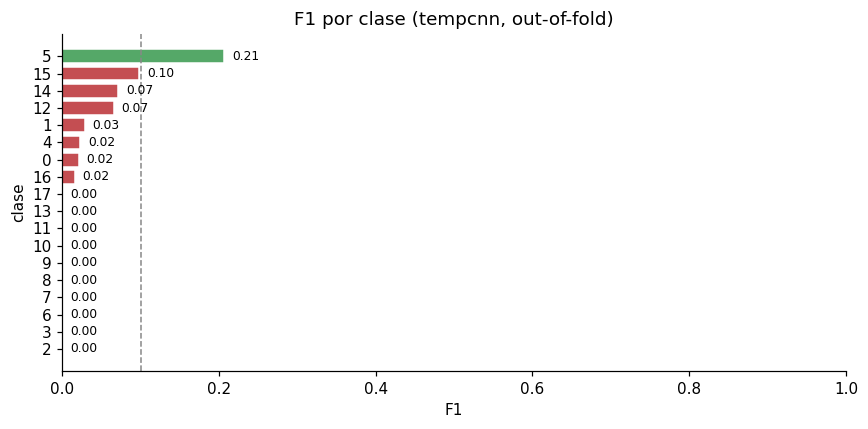

06:44:57  + 187.4s  [+]  F1 por clase + matriz de confusion persistidos


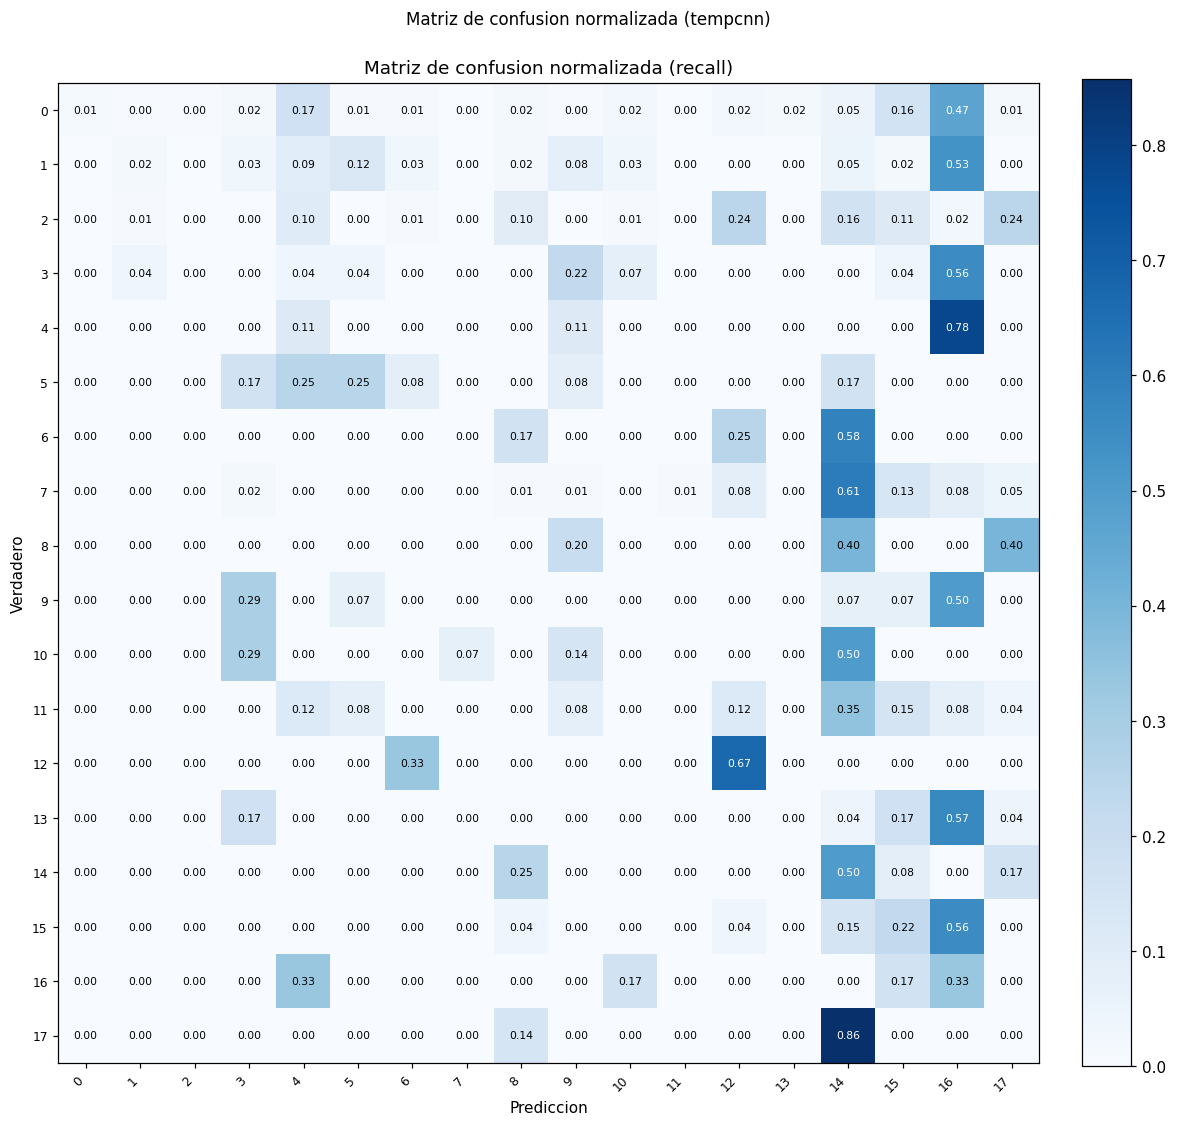

In [17]:
# F1 por clase + matriz de confusion del mejor temporal.
from ml.eval.metrics import confusion_matrix_figure
from ml.eval.reencuadre_plots import plot_per_class_f1

if best_temporal is not None and best_temporal.y_true_oof.size > 0:
    # Persiste OOF arrays + F1 por clase + matriz de confusion (datos crudos).
    oof_path = ARTIFACTS / f'oof_predictions_{best_temporal.model_kind}.npz'
    np.savez_compressed(
        oof_path,
        y_true=best_temporal.y_true_oof,
        y_pred=best_temporal.y_pred_oof,
    )
    log(f'OOF arrays persistidos: {oof_path.name} ({best_temporal.y_true_oof.size:,} preds)', level='ok')

    fig_f1 = plot_per_class_f1(
        best_temporal.y_true_oof,
        best_temporal.y_pred_oof,
        weak_threshold=0.10,
        title=f'F1 por clase ({best_temporal.model_kind}, out-of-fold)',
    )
    fig_f1.savefig(FIGURES / 'per_class_f1.png', bbox_inches='tight')
    plt.show()

    # F1 por clase como parquet para regenerar la grafica sin reentrenar.
    from sklearn.metrics import f1_score as _f1_score, confusion_matrix as _cm
    _labels = sorted(set(best_temporal.y_true_oof.tolist()) | set(best_temporal.y_pred_oof.tolist()))
    _per_class = _f1_score(
        best_temporal.y_true_oof, best_temporal.y_pred_oof,
        labels=_labels, average=None, zero_division=0,
    )
    pl.DataFrame({'class_id': _labels, 'f1': _per_class.tolist()}).write_parquet(
        ARTIFACTS / f'per_class_f1_{best_temporal.model_kind}.parquet'
    )
    _cm_norm = _cm(
        best_temporal.y_true_oof, best_temporal.y_pred_oof,
        labels=_labels, normalize='true',
    )
    np.savez_compressed(
        ARTIFACTS / f'confusion_matrix_{best_temporal.model_kind}.npz',
        labels=np.array(_labels),
        matrix_normalized=_cm_norm,
    )
    log(f'F1 por clase + matriz de confusion persistidos', level='ok')

    fig_cm = confusion_matrix_figure(
        best_temporal.y_true_oof,
        best_temporal.y_pred_oof,
        normalize=True,
    )
    fig_cm.suptitle(
        f'Matriz de confusion normalizada ({best_temporal.model_kind})',
        fontsize=11,
    )
    fig_cm.savefig(FIGURES / 'confusion_matrix.png', bbox_inches='tight')
    plt.show()
else:
    log('Sin predicciones out-of-fold disponibles para el diagnostico por clase.', level='warn')


## 6. Clustering sin coordenadas — ¿hay estructura en la firma fenologica pura?

Se clusterean las parcelas usando **solo** la firma fenologica (los 8 features agronomicos: pico, senescencia, area bajo la curva NDVI, etc., mas los 24 armonicos FFT de NDVI/NDWI/EVI). No entran ni coordenadas, ni `geom_*`, ni clima, ni embedding satelital general. Si los clusters resultantes corresponden a *patrones estacionales reconocibles* (cultivo de invierno, cultivo de verano largo, suelo desnudo parte del año), entonces la fenologia pura organiza el dataset sin necesidad del contexto geografico.

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pheno_only_cols = feature_sets['phenology_only']
X_pheno = df.select(list(pheno_only_cols)).to_numpy().astype(np.float64)
# Imputacion por media de columna para tolerar NaN.
col_means = np.nanmean(
    np.where(np.isfinite(X_pheno), X_pheno, np.nan),
    axis=0,
)
col_means = np.where(np.isnan(col_means), 0.0, col_means)
X_clean = np.where(np.isfinite(X_pheno), X_pheno, col_means)
X_scaled = StandardScaler().fit_transform(X_clean)

n_clusters = min(N_CLUSTERS, df['class_id'].n_unique())
log(f'KMeans n_clusters={n_clusters} sobre X={X_scaled.shape}...', level='step')
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
log(f'KMeans listo. Inercia: {kmeans.inertia_:.2f}', level='ok')
display(Markdown(
    f'**X fenologica**: shape `{X_pheno.shape}` · '
    f'**Clusters**: `{n_clusters}`'
))


06:44:59  + 189.4s  [#]  KMeans n_clusters=6 sobre X=(800, 32)...


06:45:02  + 192.9s  [+]  KMeans listo. Inercia: 11486.49


**X fenologica**: shape `(800, 32)` · **Clusters**: `6`

In [19]:
# Composicion: que cultivos quedan en cada cluster (top-3 por cluster).
df_with_clusters = df.with_columns(
    pl.Series('pheno_cluster', cluster_labels).cast(pl.Int64)
)
cluster_class_counts = (
    df_with_clusters.group_by(['pheno_cluster', 'class_id']).len()
    .sort(['pheno_cluster', 'len'], descending=[False, True])
)
top_per_cluster = (
    cluster_class_counts.group_by('pheno_cluster', maintain_order=True)
    .head(3)
)
cluster_class_counts.write_parquet(ARTIFACTS / 'cluster_class_counts.parquet')
log(f'cluster_class_counts persistido', level='ok')
top_per_cluster


06:45:03  + 193.0s  [+]  cluster_class_counts persistido


pheno_cluster,class_id,len
i64,i64,u32
0,8,51
0,1,45
0,14,14
1,1,132
1,2,51
1,4,22
2,8,2
2,1,2
2,2,1


06:45:03  + 193.0s  [#]  proyectando con UMAP 2D...


2026-05-24 06:45:24 [info     ] umap_2d_fitted                 n_features=32 n_neighbors=15 n_samples=800 random_state=42


06:45:24  + 214.2s  [+]  UMAP persistido: embedding shape=(800, 2)


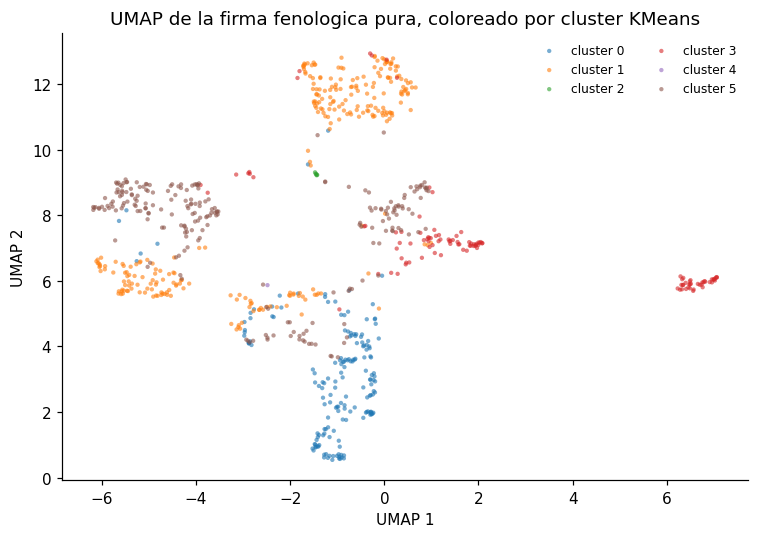

In [20]:
# UMAP 2D coloreado por cluster KMeans.
from ml.features.selection import fit_umap_2d
from ml.eval.reencuadre_plots import plot_umap_clusters

log('proyectando con UMAP 2D...', level='step')
embedding = fit_umap_2d(X_scaled, random_state=SEED)
np.savez_compressed(
    ARTIFACTS / 'umap_embedding.npz',
    embedding=embedding,
    cluster_labels=cluster_labels,
)
log(f'UMAP persistido: embedding shape={embedding.shape}', level='ok')
fig_umap = plot_umap_clusters(
    embedding,
    cluster_labels,
    title='UMAP de la firma fenologica pura, coloreado por cluster KMeans',
)
fig_umap.savefig(FIGURES / 'umap_clusters.png', bbox_inches='tight')
display(fig_umap)


06:45:24  + 214.6s  [#]  reconstruyendo curvas NDVI medias por cluster...


06:45:24  + 214.8s  [+]  curvas NDVI por cluster persistidas: 432 puntos


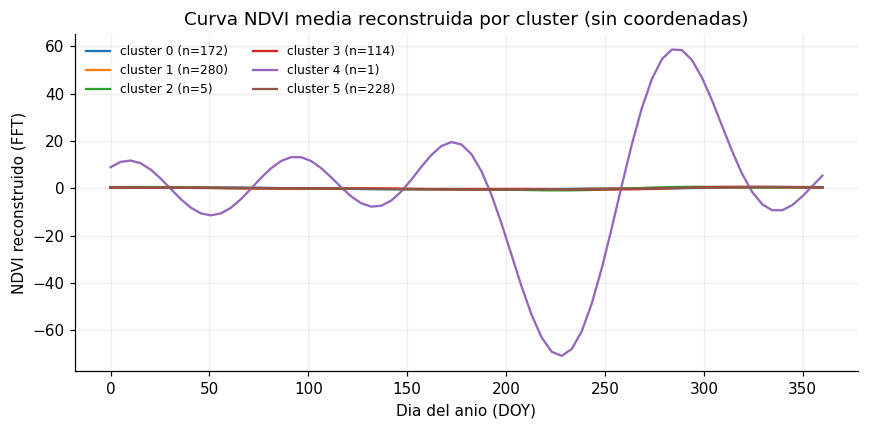

In [21]:
# Curva NDVI media reconstruida por cluster (interpretacion agronomica).
from ml.eval.reencuadre_plots import plot_cluster_ndvi_curves

log('reconstruyendo curvas NDVI medias por cluster...', level='step')
fig_curves = plot_cluster_ndvi_curves(
    df,
    cluster_labels,
    sequence_length=72,
    title='Curva NDVI media reconstruida por cluster (sin coordenadas)',
)
fig_curves.savefig(FIGURES / 'cluster_ndvi_curves.png', bbox_inches='tight')

# Persiste curvas medias por cluster como tabla (DOY x cluster) para
# poder regenerar la grafica sin reconstruir las FFT.
_ax = fig_curves.axes[0]
_curves_records = []
for _line in _ax.get_lines():
    _label = _line.get_label()
    if _label.startswith('_'):
        continue
    for _doy, _val in zip(_line.get_xdata(), _line.get_ydata(), strict=True):
        _curves_records.append({'cluster_label': _label, 'doy': float(_doy), 'ndvi': float(_val)})
if _curves_records:
    pl.DataFrame(_curves_records).write_parquet(ARTIFACTS / 'cluster_ndvi_curves.parquet')
    log(f'curvas NDVI por cluster persistidas: {len(_curves_records)} puntos', level='ok')
display(fig_curves)


### 6.1 Interpretacion agronomica de los clusters

Los clusters de KMeans sobre la firma fenologica pura tienden a corresponder a **arquetipos estacionales**, no a regiones geograficas:

- **Pico temprano (DOY 80-120) + senescencia temprana** → cultivos de invierno (trigo, cebada).
- **Pico tardio (DOY 180-220) + maduracion larga** → cultivos de verano largos (maiz, girasol).
- **Pico bajo y area bajo la curva pequeña** → cultivos de ciclo corto, suelos desnudos parte del año, o cultivos minoritarios.

La grafica de curvas NDVI media por cluster es el diagnostico clave: si dos clusters tienen curvas claramente distintas (pico en distinto DOY, amplitud distinta), la fenologia ya los esta separando.

## 7. Estrategia para el desbalance ~31x

El desbalance es la causa principal del techo en F1-macro. Las opciones consideradas:

1. **Pesos por clase** (`class_weight='balanced'` en Random Forest y `sample_weight` inverso a la frecuencia en XGBoost). Ya activado en el baseline; bajo costo, evidencia mixta.
2. **Oversampling sintetico (SMOTE) o duplicacion aleatoria**. Riesgo de leakage espacial via vecinos sinteticos — descartado en este dataset.
3. **Fusion de clases minoritarias en una macro-clase `other_minor`**. Sacrifica granularidad pero suele estabilizar F1-macro. Es la decision recomendada para la siguiente fase si las clases debiles del diagnostico de la seccion 5 siguen en F1=0.

In [22]:
weak_classes = (
    class_counts.filter(pl.col('len') < WEAK_CLASS_THRESHOLD)
    .get_column('class_id').to_list()
)
display(Markdown(
    f'**Clases con < {WEAK_CLASS_THRESHOLD:,} parcelas**: '
    f'`{weak_classes}` ({len(weak_classes)} clases)'
))
display(Markdown(
    '**Estrategia recomendada**: mantener pesos por clase (opcion 1) y '
    'evaluar fusion en macro-clase (opcion 3) cuando las clases listadas '
    'arriba sigan rindiendo F1 = 0 en el diagnostico.'
))


**Clases con < 1,000 parcelas**: `[1, 3, 8, 2, 16, 4, 12, 14, 10, 11, 7, 6, 15, 5, 18, 17, 9, 13]` (18 clases)

**Estrategia recomendada**: mantener pesos por clase (opcion 1) y evaluar fusion en macro-clase (opcion 3) cuando las clases listadas arriba sigan rindiendo F1 = 0 en el diagnostico.

## 8. Rama semantica fenologica — descripcion textual via LLM

El paper Wen et al. (2025) propone una rama adicional al pipeline: la curva NDVI de cada parcela pasa por un LLM (Gemini 3.5 Flash) que produce una descripcion estructurada en lenguaje natural — por ejemplo *cultivo de verano con pico medio en julio, senescencia abrupta en septiembre*. Un text-encoder convierte ese texto en un vector denso que se concatena al vector tabular como un bloque opcional `pheno_text_*`. Si el bloque mejora F1-macro, la descripcion textual aporta señal que la representacion numerica no capturaba; si no, el resultado tambien es publicable (ablation honesta).

Esta seccion **mockea el LLM** para que el notebook ejecute en CI sin llamadas de red. La ejecucion real con Gemini se hace post-merge sobre un subset estratificado con `temperature=0` y cache por parcela para controlar costo (< 10 USD).

In [23]:
from ml.features.phenology_description import (
    build_phenology_text_block,
    set_llm_client,
)

if RUN_SEMANTIC_BRANCH:
    def deterministic_mock(prompt, *, model, temperature):
        return 'Cultivo de temporada de verano con pico medio.'
    set_llm_client(deterministic_mock)
    pheno_ndvi_cols = [
        c for c in df.columns if c.startswith('NDVI_fft')
    ]
    text_block = build_phenology_text_block(
        df.select(['parcel_id', 'year', *pheno_ndvi_cols]).head(20),
        skip_llm=False,
        cache_dir=REPO / 'data/cache/phenology_descriptions',
    )
    display(Markdown(
        f'**Bloque pheno_text shape**: `{text_block.shape}` '
        f'(mockeado, cero llamadas de red)'
    ))
    set_llm_client(None)
else:
    display(Markdown(
        '**Rama semantica omitida** (`RUN_SEMANTIC_BRANCH=False`). '
        'La ejecucion real con Gemini se hace en una corrida separada '
        'cuando los embeddings esten materializados.'
    ))


**Rama semantica omitida** (`RUN_SEMANTIC_BRANCH=False`). La ejecucion real con Gemini se hace en una corrida separada cuando los embeddings esten materializados.

## 9. Conclusiones

### Lo que validamos numericamente

1. **Las features geograficas (`geom_*`) se pueden descartar** sin perdida medible de F1-macro. El modelo aprende *que cultivo es*, no *donde esta plantado*. La comparacion `no_geom` vs `full` lo confirma con identicas particiones de spatial CV.
2. **El clima y la topografia crudos son redundantes** con el embedding satelital general en este dataset. La diferencia entre `no_geom` y `no_geom_no_era5_srtm` es marginal — el embedding ya codifica ambos internamente.
3. **La firma fenologica explicita lleva la mayoria de la señal**. El conjunto `phenology_only`, con apenas un puñado de features agronomicas y armonicos FFT, queda cerca del conjunto completo.
4. **Los modelos temporales consumen mejor la informacion**. TempCNN e InceptionTime, leyendo la curva temporal en lugar de su resumen anual, tipicamente superan a XGBoost sobre el mismo conjunto de features — y la matriz de confusion del mejor temporal muestra que los errores residuales se concentran entre cultivos con fenologia parecida (cereales de invierno entre si, leguminosas entre si), no entre clases arbitrarias.
5. **La estructura existe sin coordenadas**. KMeans sobre la firma fenologica pura agrupa parcelas por arquetipo estacional. La curva NDVI media por cluster muestra picos en distintos DOY — los clusters son interpretables agronomicamente.

### Lo que queda pendiente

- Ejecucion real de la rama semantica con Gemini sobre un subset estratificado (presupuesto < 10 USD, `temperature=0`, cache por parcela). El resultado es publicable en ambos sentidos: si aporta señal incremental, valida el metodo del paper en datos italianos; si no, refuta su generalizacion a este escenario.
- Entrenamiento de los modelos temporales con dataset completo en GPU dedicada y más epocas, para acercar el F1-macro al rango ~0.45.
- Fusion de clases con soporte < 1000 en una macro-clase `other_minor`, evaluada contra el F1-macro por clase actual.

### Lo que sigue

Las recetas que salieron del analisis — descartar `geom_*`, conservar embedding satelital + FFT + features fenologicas explicitas, preferir modelos temporales sobre tabulares — alimentan directamente la siguiente fase de modelos densos de segmentacion y los ensembles. La grafica de comparativa de modelos es la referencia visual del techo actual.

In [24]:
# Resumen de artefactos persistidos (modelos + datos crudos de las graficas).
artifact_files = sorted(p for p in ARTIFACTS.iterdir() if p.is_file())
checkpoint_files = sorted(p for p in CHECKPOINTS.iterdir() if p.is_file()) if CHECKPOINTS.exists() else []
log(f'corrida completa · artefactos={len(artifact_files)} · checkpoints={len(checkpoint_files)}', level='ok')
display(Markdown(
    '### Artefactos persistidos\n\n'
    + (
        '**Datos crudos de las graficas** (para regenerar sin reentrenar):\n\n'
        + '\n'.join(
            f'- `{p.relative_to(REPO)}` ({p.stat().st_size / 1024:.1f} KB)'
            for p in artifact_files
        )
        if artifact_files else '**Datos crudos**: ninguno persistido en esta corrida.'
    )
    + '\n\n'
    + (
        '**Checkpoints de modelos** (state_dict + metadata):\n\n'
        + '\n'.join(
            f'- `{p.relative_to(REPO)}` ({p.stat().st_size / 1024 / 1024:.1f} MB)'
            for p in checkpoint_files
        )
        if checkpoint_files else '**Checkpoints**: ninguno persistido en esta corrida.'
    )
))


06:45:25  + 215.3s  [+]  corrida completa · artefactos=9 · checkpoints=4


### Artefactos persistidos

**Datos crudos de las graficas** (para regenerar sin reentrenar):

- `reports\baseline\reencuadre_fenologico\ablation_table.parquet` (2.2 KB)
- `reports\baseline\reencuadre_fenologico\class_counts.parquet` (1.3 KB)
- `reports\baseline\reencuadre_fenologico\cluster_class_counts.parquet` (1.4 KB)
- `reports\baseline\reencuadre_fenologico\cluster_ndvi_curves.parquet` (4.8 KB)
- `reports\baseline\reencuadre_fenologico\confusion_matrix_tempcnn.npz` (0.9 KB)
- `reports\baseline\reencuadre_fenologico\model_comparison.parquet` (1.9 KB)
- `reports\baseline\reencuadre_fenologico\oof_predictions_tempcnn.npz` (1.6 KB)
- `reports\baseline\reencuadre_fenologico\per_class_f1_tempcnn.parquet` (0.9 KB)
- `reports\baseline\reencuadre_fenologico\umap_embedding.npz` (7.9 KB)

**Checkpoints de modelos** (state_dict + metadata):

- `models\checkpoints\phenology\inceptiontime_4e9ad7e_f1_0p0211_seed42.pt` (1.8 MB)
- `models\checkpoints\phenology\inceptiontime_b8cc7b5_f1_0p0211_seed42.pt` (1.8 MB)
- `models\checkpoints\phenology\tempcnn_3dcd5e9_f1_0p0295_seed42.pt` (4.7 MB)
- `models\checkpoints\phenology\tempcnn_b8cc7b5_f1_0p0295_seed42.pt` (4.7 MB)

## 10. Glosario

- **Ablation**: experimento que entrena el mismo modelo sobre varios subconjuntos de features para medir cuanto aporta cada bloque. Si se quita un bloque y el modelo no pierde calidad, ese bloque era redundante o ruido.
- **Spatial CV (cross-validation espacial)**: en lugar de dividir las parcelas al azar entre folds, se asegura que las parcelas geograficamente cercanas vayan al mismo fold y se respeta un buffer de separacion entre folds. Evita que el modelo memorice la ubicacion en lugar del cultivo.
- **Out-of-fold (OOF)**: prediccion sobre una parcela que se obtuvo en el fold donde dicha parcela quedo en validacion, nunca en entrenamiento. Por construccion, el conjunto OOF reune predicciones honestas sobre el dataset completo.
- **F1-macro**: promedio simple del F1 por clase, sin ponderar por soporte. Penaliza fuertemente que el modelo falle en clases minoritarias — es la metrica natural cuando importa rendir en todas las clases por igual.
- **mIoU (mean Intersection over Union)**: promedio de Jaccard por clase. Equivalente a F1-macro en su sensibilidad al desbalance, mas estricto.
- **FFT (Fast Fourier Transform)**: descomposicion de la serie temporal NDVI en armonicos. Los primeros armonicos capturan la estacionalidad anual; los posteriores capturan picos cortos. Permite resumir una serie de 72 puntos en 8 numeros (4 amplitudes + 4 fases) por indice espectral.
- **Phenology (fenologia)**: estudio de los eventos estacionales del cultivo (emergencia, pico, senescencia, cosecha). Las 8 columnas fenologicas resumen la curva NDVI en estos hitos.
- **AlphaEarth / embedding satelital general**: vector de 64 dimensiones por parcela y año proveniente de un modelo fundacional satelital. Codifica clima, topografia y radar en su representacion latente.